In [1]:
from pathlib import Path
import shutil
import random
from PIL import Image
import numpy as np

ROOT = Path.cwd()

if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent

LEvir_ROOT = ROOT / "LEVIR-CD+"
OUTPUT = ROOT / "data" / "levir_cd"

print("Project root:", ROOT)
print("LEVIR-CD+:", LEvir_ROOT)
print("Output:", OUTPUT)

print("Dataset exists:", LEvir_ROOT.exists())

Project root: c:\Users\shreyas\Documents\UrbanWatch
LEVIR-CD+: c:\Users\shreyas\Documents\UrbanWatch\LEVIR-CD+
Output: c:\Users\shreyas\Documents\UrbanWatch\data\levir_cd
Dataset exists: True


In [2]:
for split in ["train", "test"]:
    for folder in ["A", "B", "labels"]:
        (OUTPUT / split / folder).mkdir(
            parents=True,
            exist_ok=True
        )

print("Output directories created.")

Output directories created.


In [3]:
for split in ["train", "test"]:

    a_dir = LEvir_ROOT / split / "A"
    b_dir = LEvir_ROOT / split / "B"
    label_dir = LEvir_ROOT / split / "label"

    a_files = {
        p.name for p in a_dir.glob("*.png")
    }

    b_files = {
        p.name for p in b_dir.glob("*.png")
    }

    label_files = {
        p.name for p in label_dir.glob("*.png")
    }

    common = (
        a_files &
        b_files &
        label_files
    )

    print("\n", split.upper())
    print("A:", len(a_files))
    print("B:", len(b_files))
    print("Labels:", len(label_files))
    print("Complete pairs:", len(common))

    print("Missing A:", len(
        (b_files & label_files) - a_files
    ))

    print("Missing B:", len(
        (a_files & label_files) - b_files
    ))

    print("Missing labels:", len(
        (a_files & b_files) - label_files
    ))


 TRAIN
A: 637
B: 637
Labels: 637
Complete pairs: 637
Missing A: 0
Missing B: 0
Missing labels: 0

 TEST
A: 348
B: 348
Labels: 348
Complete pairs: 348
Missing A: 0
Missing B: 0
Missing labels: 0


In [4]:
for split in ["train", "test"]:

    a_dir = LEvir_ROOT / split / "A"
    b_dir = LEvir_ROOT / split / "B"
    label_dir = LEvir_ROOT / split / "label"

    common = sorted(
        {
            p.name for p in a_dir.glob("*.png")
        }
        &
        {
            p.name for p in b_dir.glob("*.png")
        }
        &
        {
            p.name for p in label_dir.glob("*.png")
        }
    )

    for filename in common:

        shutil.copy2(
            a_dir / filename,
            OUTPUT / split / "A" / filename
        )

        shutil.copy2(
            b_dir / filename,
            OUTPUT / split / "B" / filename
        )

        shutil.copy2(
            label_dir / filename,
            OUTPUT / split / "labels" / filename
        )

    print(
        f"{split}: copied {len(common)} complete pairs"
    )

train: copied 637 complete pairs
test: copied 348 complete pairs


In [5]:
for split in ["train", "test"]:

    a_files = sorted(
        (OUTPUT / split / "A").glob("*.png")
    )

    invalid = 0
    changed_pixels = 0
    total_pixels = 0

    for a_path in a_files:

        name = a_path.name

        a = np.array(
            Image.open(
                OUTPUT / split / "A" / name
            )
        )

        b = np.array(
            Image.open(
                OUTPUT / split / "B" / name
            )
        )

        label = np.array(
            Image.open(
                OUTPUT / split / "labels" / name
            )
        )

        if (
            a.shape != (1024, 1024, 3)
            or b.shape != (1024, 1024, 3)
            or label.shape != (1024, 1024)
        ):
            invalid += 1

        unique = np.unique(label)

        if not set(unique).issubset({0, 255}):
            print(
                "Unexpected label values:",
                name,
                unique
            )

        changed_pixels += np.sum(label == 255)
        total_pixels += label.size

    print("\n", split.upper())
    print("Samples:", len(a_files))
    print("Invalid dimensions:", invalid)
    print(
        "Changed-pixel ratio:",
        changed_pixels / total_pixels
    )

Unexpected label values: train_100.png [  0 156 255]
Unexpected label values: train_101.png [  0 156 255]
Unexpected label values: train_218.png [  0 254 255]
Unexpected label values: train_263.png [  0 254 255]
Unexpected label values: train_271.png [  0 156 255]
Unexpected label values: train_272.png [  0 156 255]
Unexpected label values: train_273.png [  0 156 255]
Unexpected label values: train_275.png [  0 156 255]
Unexpected label values: train_278.png [  0 156 255]
Unexpected label values: train_279.png [  0 156 255]
Unexpected label values: train_280.png [  0 156 255]
Unexpected label values: train_282.png [  0 156 255]
Unexpected label values: train_287.png [  0 156 255]
Unexpected label values: train_288.png [  0 156 255]
Unexpected label values: train_289.png [  0 156 255]
Unexpected label values: train_291.png [  0 156 255]
Unexpected label values: train_292.png [  0 156 255]
Unexpected label values: train_293.png [  0 156 255]
Unexpected label values: train_294.png [  0 15

In [8]:
from pathlib import Path
from PIL import Image
import numpy as np

for split in ["train", "test"]:

    label_dir = OUTPUT / split / "labels"

    fixed = 0

    for label_path in label_dir.glob("*.png"):

        mask = np.array(
            Image.open(label_path)
        )

        # Convert every non-zero pixel to 255
        normalized = np.where(
            mask > 0,
            255,
            0
        ).astype(np.uint8)

        if not np.array_equal(mask, normalized):
            Image.fromarray(normalized).save(label_path)
            fixed += 1

    print(
        f"{split}: normalized {fixed} masks"
    )

train: normalized 32 masks
test: normalized 0 masks


In [9]:
for split in ["train", "test"]:

    label_dir = OUTPUT / split / "labels"

    values = set()

    for label_path in label_dir.glob("*.png"):

        mask = np.array(
            Image.open(label_path)
        )

        values.update(
            np.unique(mask).tolist()
        )

    print(split, "label values:", sorted(values))

train label values: [0, 255]
test label values: [0, 255]


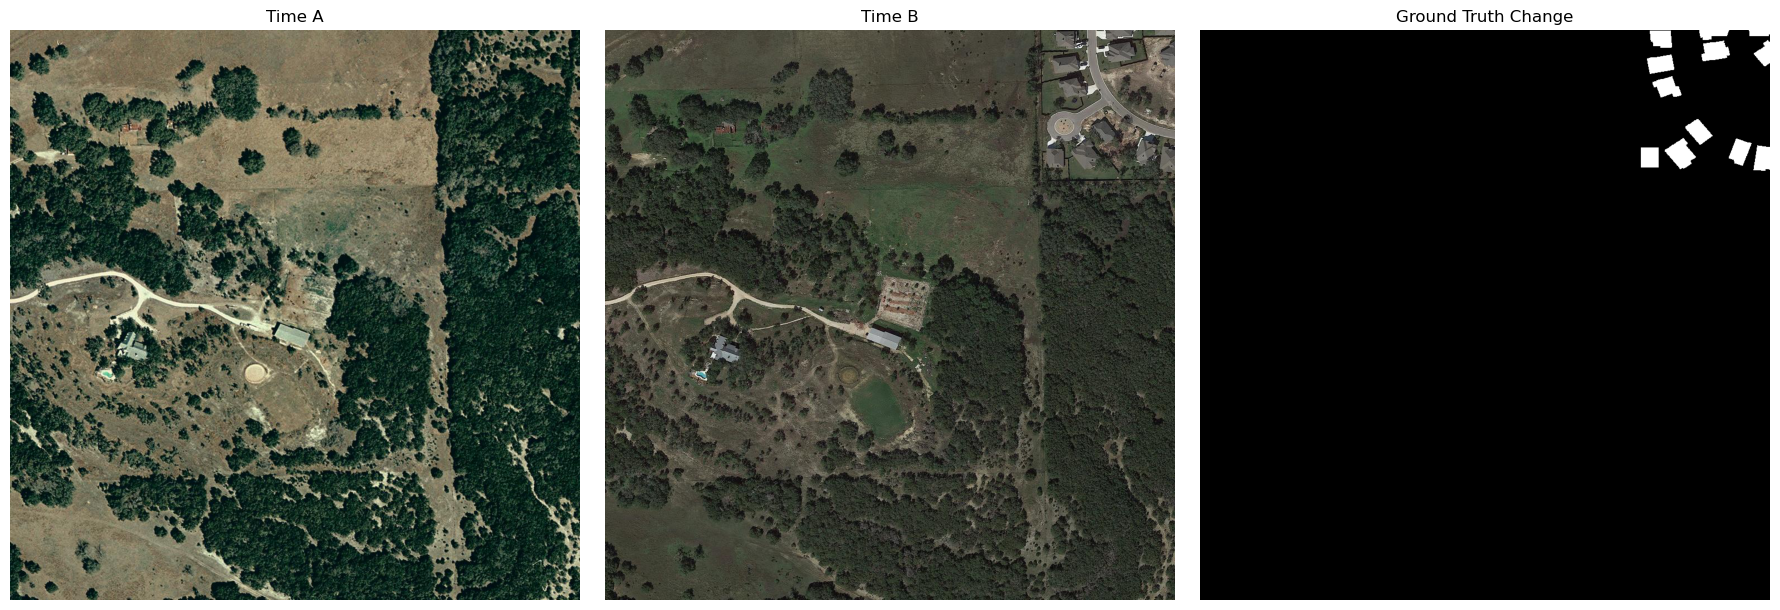

A shape: (1024, 1024, 3)
B shape: (1024, 1024, 3)
Label shape: (1024, 1024)
Changed pixels: 13189
Change percentage: 1.26 %


In [10]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

sample = "train_1.png"

A = np.array(
    Image.open(OUTPUT / "train" / "A" / sample)
)

B = np.array(
    Image.open(OUTPUT / "train" / "B" / sample)
)

label = np.array(
    Image.open(OUTPUT / "train" / "labels" / sample)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(A)
axes[0].set_title("Time A")
axes[0].axis("off")

axes[1].imshow(B)
axes[1].set_title("Time B")
axes[1].axis("off")

axes[2].imshow(label, cmap="gray")
axes[2].set_title("Ground Truth Change")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("A shape:", A.shape)
print("B shape:", B.shape)
print("Label shape:", label.shape)
print("Changed pixels:", np.sum(label == 255))
print(
    "Change percentage:",
    round(np.mean(label == 255) * 100, 2),
    "%"
)

In [7]:
import json

metadata = {}

for split in ["train", "test"]:

    files = sorted(
        (OUTPUT / split / "A").glob("*.png")
    )

    metadata[split] = {
        "samples": len(files),
        "image_size": [1024, 1024],
        "channels": 3,
        "label_values": [0, 255],
    }

metadata_path = OUTPUT / "metadata.json"

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print(json.dumps(metadata, indent=4))
print("\nSaved:", metadata_path)

{
    "train": {
        "samples": 637,
        "image_size": [
            1024,
            1024
        ],
        "channels": 3,
        "label_values": [
            0,
            255
        ]
    },
    "test": {
        "samples": 348,
        "image_size": [
            1024,
            1024
        ],
        "channels": 3,
        "label_values": [
            0,
            255
        ]
    }
}

Saved: c:\Users\shreyas\Documents\UrbanWatch\data\levir_cd\metadata.json


In [11]:
from pathlib import Path
import shutil
import random

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

ROOT = Path.cwd()

if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent

LEvir_OUTPUT = ROOT / "data" / "levir_cd"

SOURCE = LEvir_OUTPUT / "train"

# New split location
SPLIT_OUTPUT = LEvir_OUTPUT / "split"

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

SEED = 42
VAL_RATIO = 0.20

random.seed(SEED)

# ------------------------------------------------------------
# Find complete pairs
# ------------------------------------------------------------

A_FILES = {
    p.name
    for p in (SOURCE / "A").glob("*.png")
}

B_FILES = {
    p.name
    for p in (SOURCE / "B").glob("*.png")
}

LABEL_FILES = {
    p.name
    for p in (SOURCE / "labels").glob("*.png")
}

pairs = sorted(
    A_FILES &
    B_FILES &
    LABEL_FILES
)

print("Complete pairs:", len(pairs))

# ------------------------------------------------------------
# Shuffle reproducibly
# ------------------------------------------------------------

random.shuffle(pairs)

val_count = int(len(pairs) * VAL_RATIO)

val_pairs = pairs[:val_count]
train_pairs = pairs[val_count:]

print("\nSplit:")
print("Training:", len(train_pairs))
print("Validation:", len(val_pairs))

# ------------------------------------------------------------
# Create directories
# ------------------------------------------------------------

for split in ["train", "val"]:

    for folder in ["A", "B", "labels"]:

        (
            SPLIT_OUTPUT
            / split
            / folder
        ).mkdir(
            parents=True,
            exist_ok=True
        )

# ------------------------------------------------------------
# Copy files
# ------------------------------------------------------------

def copy_pairs(pair_list, split):

    for filename in pair_list:

        for folder in ["A", "B", "labels"]:

            source_file = (
                SOURCE
                / folder
                / filename
            )

            destination_file = (
                SPLIT_OUTPUT
                / split
                / folder
                / filename
            )

            shutil.copy2(
                source_file,
                destination_file
            )


copy_pairs(train_pairs, "train")
copy_pairs(val_pairs, "val")

print("\nSplit created successfully.")

print(
    "Train:",
    SPLIT_OUTPUT / "train"
)

print(
    "Validation:",
    SPLIT_OUTPUT / "val"
)

Complete pairs: 637

Split:
Training: 510
Validation: 127

Split created successfully.
Train: c:\Users\shreyas\Documents\UrbanWatch\data\levir_cd\split\train
Validation: c:\Users\shreyas\Documents\UrbanWatch\data\levir_cd\split\val


In [12]:
for split in ["train", "val"]:

    print("\n" + "=" * 60)
    print(split.upper())
    print("=" * 60)

    for folder in ["A", "B", "labels"]:

        count = len(
            list(
                (
                    SPLIT_OUTPUT
                    / split
                    / folder
                ).glob("*.png")
            )
        )

        print(f"{folder:8}: {count}")


TRAIN
A       : 510
B       : 510
labels  : 510

VAL
A       : 127
B       : 127
labels  : 127


In [13]:
for split in ["train", "val"]:

    a = {
        p.name
        for p in (
            SPLIT_OUTPUT / split / "A"
        ).glob("*.png")
    }

    b = {
        p.name
        for p in (
            SPLIT_OUTPUT / split / "B"
        ).glob("*.png")
    }

    labels = {
        p.name
        for p in (
            SPLIT_OUTPUT / split / "labels"
        ).glob("*.png")
    }

    print(
        split,
        "| A:", len(a),
        "| B:", len(b),
        "| Labels:", len(labels),
        "| Complete:", len(a & b & labels)
    )

train | A: 510 | B: 510 | Labels: 510 | Complete: 510
val | A: 127 | B: 127 | Labels: 127 | Complete: 127
